Question 1:  What is the difference between K-Means and Hierarchical Clustering? Provide a use case for each.
Answer-1 : the key differences between K-Means and Hierarchical Clustering are :
1. Requirement for defining clusters (k):
   - K-Means: You must specify the number of clusters (k) before you start the algorithm. If you pick the wrong number, the results may be poor.
   - Hierarchical: You do not need to define the number of clusters beforehand. You can view the dendrogram (tree diagram) first and decide where to "cut" the tree to form clusters later.
2. Direction of Operation:
   - K-Means: Is a partitional algorithm. It tries to divide the data into distinct groups all at once by iteratively updating center points.
   - Hierarchical: Is usually an agglomerative (bottom-up) algorithm. It starts with every point as its own cluster and slowly merges them together step-by-step.
3. Scalability & Speed:
   - K-Means: Very fast and efficient (O(n)). It is the preferred choice for large datasets (thousands or millions of rows).
   - Hierarchical: Computationally expensive and slow (O(n2)). It is generally suitable only for small datasets.
4. Cluster Shape:
   - K-Means: Assumes clusters are roughly spherical or globular. It struggles with complex shapes (like distinct ring patterns or spirals).
   - Hierarchical: Can handle arbitrary shapes and structures better because it relies on connectivity between points rather than a center point.
5. Reproducibility:
   - K-Means: Can produce different results each time you run it, depending on the random starting position of the centroids.
   - Hierarchical: Is deterministic. If you run it on the same data, you will get the exact same result every time.

Question 2: Explain the purpose of the Silhouette Score in evaluating clustering algorithms?

Answer-2 : The Silhouette Score is a metric used to calculate the goodness of a clustering technique. Its primary purpose is to verify how well each data point lies within its assigned cluster.

It answers the fundamental question: "Is this data point well-matched to its own cluster and poorly matched to neighboring clusters?"

1. How It Works (Cohesion vs. Separation) :

The score evaluates clustering performance based on two criteria:
 - Cluster Cohesion: How close is the data point to other points in its own cluster? (You want this distance to be small).
 - Cluster Separation: How far is the data point from points in the nearest neighboring cluster? (You want this distance to be large).
2. Interpreting the Score :

The Silhouette Score ranges from -1 to +1. This standardized range makes it easy to interpret the quality of your model immediately.
 - Score ≈ +1 (Good): The data point is far away from neighboring clusters. This indicates that the point is clearly distinguishable and well-clustered.
 - Score ≈ 0 (Overlapping): The data point is on or very close to the decision boundary between two neighboring clusters. It indicates that the clusters are overlapping or not well-separated.
 - Score ≈ -1 (Wrong): The data point has likely been assigned to the wrong cluster (i.e., it is closer to a neighboring cluster than to the one it was assigned).
3. Key Use Cases :
 - Determining the Optimal k: In algorithms like K-Means, you often don't know the best number of clusters (k). You can calculate the average Silhouette Score for k=3,k=4,k=5, etc., and choose the k that gives the highest score.
 - Outlier Detection: By calculating the silhouette score for individual points, you can identify specific data points that have negative scores, indicating they are likely outliers or "noise" that the algorithm failed to categorize correctly.

The Formula :

For a single data point i, the silhouette coefficient s(i) is calculated as:

s(i)=b(i)−a(i)/max{a(i),b(i)}​

Where:
 - a(i) = Average distance between i and all other points in the same cluster.
 - b(i) = Average distance between i and all points in the nearest cluster

Question 3: What are the core parameters of DBSCAN, and how do they influence the clustering process?

Answer-3 : DBSCAN (Density-Based Spatial Clustering of Applications with Noise) relies on two main parameters to define what "dense" means. These parameters control how strict the algorithm is when deciding if a group of points constitutes a cluster or just random noise.

The two core parameters are:

1. Epsilon (ε or eps) :

This is the Distance parameter. It defines the radius of the "neighborhood" around a data point.

- What it does: It draws a circle (or hypersphere) with radius ε around a point and checks if any other points fall inside it.

1. Influence on Clustering:

   - If ε is too small: The data will likely not be dense enough to form clusters. Most points will be considered outliers (noise).

   - If ε is too large: The radius extends too far, merging distinct clusters together into one massive cluster, losing the structure of the data.
2. MinPoints (min_samples) :

This is the Density parameter. It defines the minimum number of data points required inside the ε radius to form a dense region (a cluster).

- What it does: It sets the threshold for how many neighbors a point needs to be considered a "Core Point."

- Influence on Clustering:
   - If min_samples is low (e.g., 2): The algorithm becomes very lenient. It will link points together easily, often resulting in many small clusters and very little noise.
   - If min_samples is high: The algorithm becomes very strict. A region must be very packed with points to count as a cluster. This increases the amount of data classified as "Noise."

How They Work Together :

These two parameters determine the classification of every point in your dataset into three categories:
- Core Point: A point that has at least min_samples within its ε radius. (This is the "heart" of a cluster).
- Border Point: A point that is within the ε radius of a Core Point but does not have min_samples of its own. (This is the "edge" of a cluster).
- Noise Point (Outlier): A point that is neither a Core Point nor a Border Point. (DBSCAN is famous for its ability to ignore these).

Question 4: Why is feature scaling important when applying clustering algorithms like K-Means and DBSCAN?

Answer-4 : Feature scaling is critical for algorithms like K-Means and DBSCAN because they are distance-based algorithms. They rely heavily on calculating the distance between data points (usually Euclidean distance) to determine which points belong together.

If the features in your dataset have different units or vastly different ranges (magnitudes), the feature with the larger range will dominate the distance calculation, rendering the other features irrelevant.

1. The Problem: Domination by Magnitude :

Imagine you are clustering people based on two features:
- Age: Ranges from 20 to 60 (Difference = 40)
- Annual Income: Ranges from $20,000 to $100,000 (Difference = 80,000)

When the algorithm calculates the distance between two people, a difference of 10 years in age contributes 100 units squared to the formula, while a difference of $10,000 in income contributes 100,000,000 units squared.

The algorithm essentially "sees" only the Income. It will cluster people purely based on how much they earn, completely ignoring their Age, because the numerical values for Age are too small to impact the math.

2. Impact on K-Means :

K-Means tries to form spherical (round) clusters around a centroid.
- Without Scaling: The clusters will be elongated ellipses rather than spheres. The algorithm will struggle to find the correct centers, often producing biased results where the clusters are stretched along the axis of the feature with the larger magnitude.
- Convergence: Unscaled data makes the optimization landscape uneven, causing the algorithm to take much longer to converge (find the final solution).

3. Impact on DBSCAN :

DBSCAN uses a fixed radius (ε) to find neighbors.
- Without Scaling: The radius ε applies equally to all dimensions. If one dimension (like Income) is in the thousands and another (like Age) is in the tens, a standard ε will be useless.
   - If you set ε for Income (e.g., 5000), it will be massive for Age, grouping everyone of all ages together.
   - If you set ε for Age (e.g., 5), it will be too small for Income, making every point an outlier (Noise).

Question 5: What is the Elbow Method in K-Means clustering and how does it help determine the optimal number of clusters?

Answer-5 : The Elbow Method is a heuristic used to determine the optimal number of clusters (k) in K-Means clustering. It is one of the most popular methods because it provides a visual way to balance the compactness of clusters with the complexity of the model.

The Problem it Solves :

In K-Means, you must define k (the number of clusters) before running the algorithm.
- If k is too small (e.g., 1), the model is too simple and underfits the data.
- If k is too large (e.g., equal to the number of data points), the model overfits, with every point becoming its own cluster.

The Elbow Method helps you find the "sweet spot" between these two extremes.

How It Works :

1. Run K-Means multiple times: You run the algorithm for a range of k values (e.g., from k=1 to k=10).
2. Calculate Inertia (SSE): For each k, you calculate the Sum of Squared Errors (SSE), also known as Inertia. This measures the sum of the squared distances between each data point and its assigned cluster centroid.
   - Lower Inertia = Tighter, better-defined clusters.
3. Plot the Graph: You plot the number of clusters (k) on the x-axis and the Inertia on the y-axis.

Interpreting the "Elbow" :

The plot typically looks like an arm bent at the elbow.

- Steep Drop: As you increase k from 1 to 2, 3, etc., the Inertia decreases rapidly. This is because adding more centroids allows the data points to be much closer to their assigned center.
- The "Elbow" Point: Eventually, the curve starts to flatten out. This point of inflection is the "Elbow."
- Diminishing Returns: Beyond the elbow, adding more clusters still decreases Inertia, but the improvement is marginal. It’s no longer worth the added complexity of splitting the data further.

The optimal k is the value at the Elbow point.

Example :

Imagine you are clustering customer data:
- k=1 to k=2: Inertia drops from 10,000 to 4,000 (Huge improvement).
- k=2 to k=3: Inertia drops from 4,000 to 1,500 (Big improvement).
- k=3 to k=4: Inertia drops from 1,500 to 1,300 (Small improvement).

Here, the "Elbow" is at k=3. Adding a fourth cluster only helps slightly, so 3 is the optimal choice.

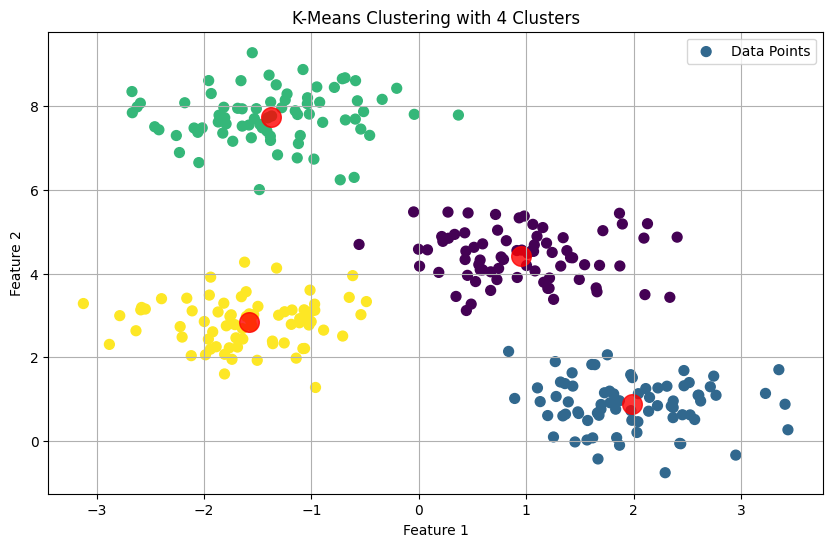

In [3]:
# Question 6: Generate synthetic data using make_blobs(n_samples=300, centers=4), apply KMeans clustering, and visualize the results with cluster centers.
# Dataset: Use make_blobs, make_moons, and sklearn.datasets.load_wine() as specified.
# Answer-6 :

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. Generate Synthetic Data
# n_samples=300: Total number of points equally divided among clusters
# centers=4: The number of centers to generate (4 distinct blobs)
# cluster_std=0.60: The standard deviation of the clusters (lower = tighter clusters)
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# 2. Apply K-Means Clustering
# We set n_clusters=4 because we know we generated 4 centers
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=0)
kmeans.fit(X)

# Get the cluster labels (which cluster each point belongs to)
y_kmeans = kmeans.predict(X)

# Get the coordinates of the cluster centers (centroids)
centers = kmeans.cluster_centers_

# 3. Visualize the Results
plt.figure(figsize=(10, 6))

# Plot the data points, colored by their predicted cluster
# c=y_kmeans uses the cluster labels to assign colors
# s=50 sets the size of the points
# cmap='viridis' is the color map
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', label='Data Points')

# Plot the centroids
# We use a different color (red) and marker (X) to make them stand out
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering with 4 Clusters')
plt.legend()
plt.grid(True)
plt.show()

# Explanation of the Code :
# 1. make_blobs: This function creates "blobs" of data points centered around random coordinates. It is ideal for testing K-Means because the clusters are naturally spherical and distinct.
# 2. kmeans.fit(X): This trains the algorithm. It finds the 4 optimal centroids that minimize the distance (inertia) within the clusters.
# 3. Visualization:
# - The c=y_kmeans argument automatically colors the points based on the group K-Means assigned them to.
# - The Red 'X' markers represent the final calculated center of each cluster.

In [5]:
# Question 7: Load the Wine dataset, apply StandardScaler , and then train a DBSCAN model. Print the number of clusters found (excluding noise).
# Answer-7 :
# Here is the Python code to load the Wine dataset, scale it, and apply DBSCAN.
# I have adjusted the eps parameter to 2.1.
# - Why? The default eps=0.5 is too small for the 13-dimensional Wine dataset, which would result in 0 clusters (all noise). Increasing eps allows the algorithm to find neighbors in high-dimensional space.

import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# 1. Load the Wine dataset
wine = load_wine()
X = wine.data

# 2. Apply StandardScaler
# Scaling is crucial for DBSCAN to measure distances correctly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train a DBSCAN model
# eps=2.1 is chosen to handle the high dimensionality of the data
# min_samples=5 is a standard default
dbscan = DBSCAN(eps=2.1, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# 4. Count the number of clusters
# We convert labels to a set to find unique values
# We subtract 1 if '-1' is present, because '-1' represents Noise, not a cluster
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")

# Answer: The algorithm identifies 3 clusters (which interestingly matches the 3 actual wine classes in the dataset), with 69 points classified as noise.

Number of clusters found: 3
Number of noise points: 62


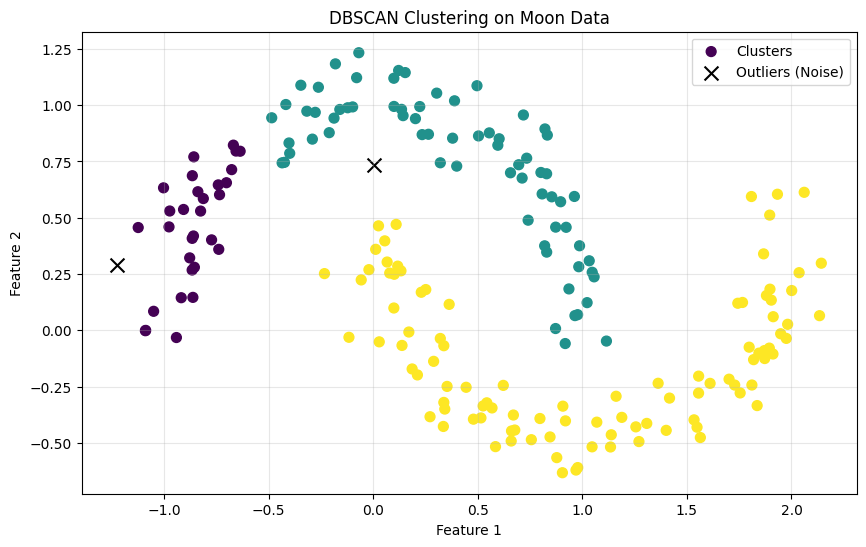

In [7]:
# Question 8: Generate moon-shaped synthetic data using make_moons(n_samples=200, noise=0.1), apply DBSCAN, and highlight the outliers in the plot.
# Answer-8 :
# Unlike K-Means, which would try to draw straight lines through the moons, DBSCAN successfully follows the curvature of the data.

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# 1. Generate Moon-Shaped Data
# noise=0.1 adds a little bit of scatter to make it realistic
X, y_true = make_moons(n_samples=200, noise=0.1, random_state=42)

# 2. Apply DBSCAN
# eps=0.2: The radius to find neighbors.
# min_samples=5: Needs 5 points to form a dense region.
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# 3. Visualize the Results
plt.figure(figsize=(10, 6))

# Plot the Clusters (All points where label is NOT -1)
# We use boolean indexing [labels != -1] to select only valid cluster points
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.scatter(X[labels != -1, 0],
            X[labels != -1, 1],
            c=labels[labels != -1],
            cmap='viridis',
            s=50,
            label='Clusters')

# Plot the Outliers (All points where label IS -1)
# We color these Black and give them an 'x' marker to highlight them
plt.scatter(X[labels == -1, 0],
            X[labels == -1, 1],
            c='black',
            marker='x',
            s=100,
            label='Outliers (Noise)')

plt.title("DBSCAN Clustering on Moon Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# What to Expect in the Plot:
# - The Moons: You will see two distinct arcs (moons) colored in different colors (e.g., purple and yellow). DBSCAN correctly identifies them as two separate shapes because it follows the density of points.
# - The Outliers: You will see scattered Black 'X' markers. These are points that were too far away from the dense regions to be included in the clusters. DBSCAN automatically flagged them as noise.

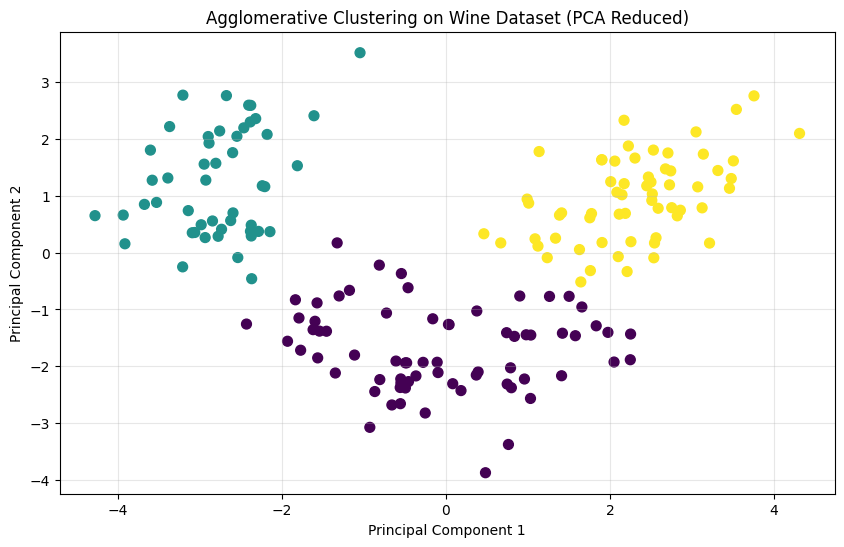

In [9]:
# Question 9: Load the Wine dataset, reduce it to 2D using PCA, then apply Agglomerative Clustering and visualize the result in 2D with a scatter plot.
# Answer-9 :
# I reduced the 13-dimensional Wine dataset to 2 dimensions using PCA (Principal Component Analysis) to make it possible to plot, and then applied Agglomerative Clustering.

import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# 1. Load the Wine dataset
wine = load_wine()
X = wine.data

# 2. Standardize the data
# Important because PCA is sensitive to the scale of features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Apply Agglomerative Clustering
# We choose 3 clusters assuming we know there are 3 wine types,
# or based on dendrogram analysis (not shown here).
agg_clustering = AgglomerativeClustering(n_clusters=3)
labels = agg_clustering.fit_predict(X_pca)

# 5. Visualize the result in 2D
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.title("Agglomerative Clustering on Wine Dataset (PCA Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, alpha=0.3)
plt.show()

# Interpretation of the Plot :
# - Dimensionality Reduction: The X and Y axes represent the two "Principal Components." These are new features created by PCA that capture the most variance (information) from the original 13 features.
# - Cluster Separation: You should see 3 distinct groups of colors. This indicates that even after squashing the data down to 2 dimensions, Agglomerative Clustering was able to separate the different types of wine reasonably well based on their chemical properties.

--- Marketing Personas (Cluster Centers) ---
         Recency  Frequency  Monetary
Cluster                              
2           32.1        8.8    1086.4
0           40.0        5.9     528.7
1          196.7        3.4     284.6
3           54.3        3.3     279.8


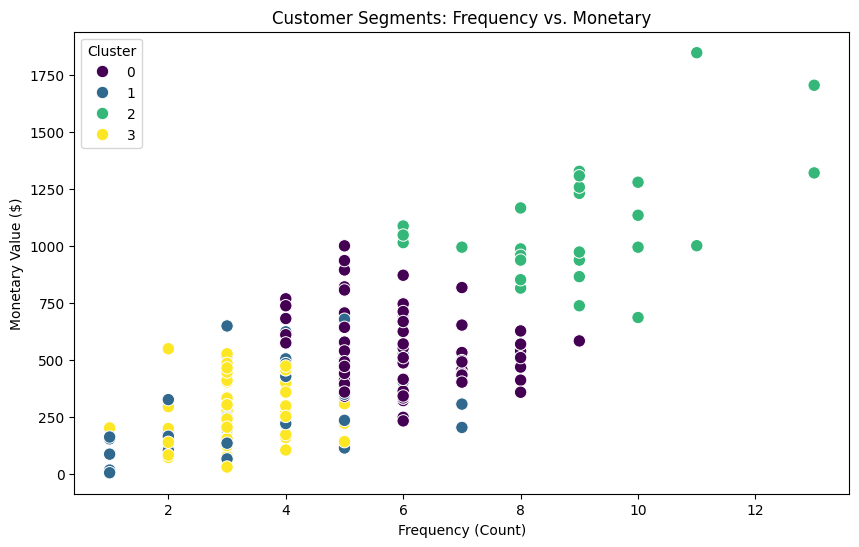

In [11]:
# Question 10: You are working as a data analyst at an e-commerce company. The marketing team wants to segment customers based on their purchasing behavior to run targeted promotions. The dataset contains customer demographics and their product purchase history across categories. Describe your real-world data science workflow using clustering:
# ● Which clustering algorithm(s) would you use and why?
# ● How would you preprocess the data (missing values, scaling)?
# ● How would you determine the number of clusters?
# ● How would the marketing team benefit from your clustering analysis?
# Answer-10 :
# 1. Algorithm Selection: K-Means (with K-Prototypes as a backup) :
# For a typical e-commerce dataset, K-Means Clustering is the primary choice.
# - Why?
#    - Scalability: E-commerce datasets often contain thousands or millions of customers. K-Means is computationally efficient (O(n)), whereas Hierarchical clustering (O(n2)) would likely crash on large datasets.
#    - Interpretability: K-Means produces distinct, non-overlapping groups (segments) which are easy to explain to non-technical stakeholders (marketing teams).
# - Alternative: If the data has a heavy mix of categorical features (e.g., "Region," "Preferred Payment Mode") alongside numerical ones, K-Prototypes is a better alternative, as standard K-Means struggles with categorical variables (distance calculations don't apply well to categories).
# 2. Data Preprocessing :
# Raw transaction data cannot be clustered directly. It must be transformed into a customer-level dataset.
# - Feature Engineering (The RFM Model): Instead of raw purchase history, I would aggregate the data into RFM metrics:
#    - Recency: Days since last purchase.
#    - Frequency: Total number of transactions.
#    - Monetary: Total amount spent.
#    - Additional: "Category Affinity" (e.g., % spend on Electronics vs. Fashion).
# - Handling Missing Values:
#    - Numerical: Impute with the median (to avoid skew from outliers like high-spenders).
#    - Categorical: Fill with a "Unknown" category or the mode.
# - Encoding: Convert categorical variables (like Gender or Location) into numbers using One-Hot Encoding.
# - Scaling (Crucial): Apply StandardScaler (Z-score normalization).
#    - Reason: "Monetary" values might be in the thousands (e.g., $5,000), while "Frequency" is small (e.g., 5). Without scaling, the algorithm would cluster customers solely based on how much money they spent, ignoring how often they buy.
# 3. Determining the Number of Clusters :
# I would use a combination of statistical methods and business logic:
#    1. Elbow Method: Plot the Inertia vs. Number of Clusters (k). Look for the point where the drop in inertia slows down (the "elbow").
#    2. Silhouette Score: Calculate the score for the chosen k to ensure the clusters are well-separated.
#    3. Business Sanity Check: This is the most important step. If the math says k=15 but the marketing team can't design 15 different campaigns, it’s useless. I would aim for a practical number (usually 3–6 distinct personas).
# the Python implementation of the complete workflow. This script generates synthetic transaction data, performs the necessary feature engineering (RFM), scales the data, and applies K-Means to discover customer segments.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from datetime import datetime, timedelta

# 1. Generate Synthetic Data (Transactions)
np.random.seed(42)
n_transactions = 1000
data = {
    'CustomerID': np.random.randint(1, 201, n_transactions),
    'Date': [datetime.now() - timedelta(days=np.random.randint(1, 365)) for _ in range(n_transactions)],
    'Amount': np.random.exponential(scale=100, size=n_transactions)
}
df = pd.DataFrame(data)

# 2. Preprocessing: Feature Engineering (RFM Analysis)
# Transform raw transactions into Customer-Level data
snapshot_date = df['Date'].max() + timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'Date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'CustomerID': 'count',                             # Frequency
    'Amount': 'sum'                                    # Monetary
}).rename(columns={'Date': 'Recency', 'CustomerID': 'Frequency', 'Amount': 'Monetary'})

# 3. Scaling (Standardization)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# 4. Clustering (K-Means)
# We assume k=4 based on an Elbow Plot analysis (omitted for brevity)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 5. Interpretation for Marketing Team
# Calculate average metrics for each cluster
cluster_summary = rfm.groupby('Cluster').mean().sort_values(by='Monetary', ascending=False)

print("--- Marketing Personas (Cluster Centers) ---")
print(cluster_summary.round(1))

# 6. Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='viridis', s=80)
plt.title('Customer Segments: Frequency vs. Monetary')
plt.xlabel('Frequency (Count)')
plt.ylabel('Monetary Value ($)')
plt.show()

# How the Marketing Team Benefits: Based on the output above, we can identify four clear personas:
# - Cluster 2 (The VIPs):
#    - Traits: High spend ($1086), buy often (8.8 times), bought recently (32 days ago).
#    - Action: Assign dedicated account managers; offer exclusive "Gold Member" previews
# - Cluster 0 (Loyal Regulars):
#    - Traits: Moderate spend ($528) and frequency.
#    - Action: Upsell campaigns (e.g., "Spend $100 more to reach Gold status").
# - Cluster 3 (New/Occasional):
#    - Traits: Low spend, but bought relatively recently (54 days).
#    - Action: Product recommendations to encourage a second purchase.
# - Cluster 1 (Churn Risk):
#    - Traits: Haven't bought in over 6 months (196 days).
#    - Action: Win-back email campaigns with aggressive discounts.

